In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pandas as pd

sal_data = pd.read_csv("employee_salary_regression.csv")
sal_data.head()

,employee_id,age,years_experience,education_level,job_role,city_tier,performance_score,num_skills,remote_work,annual_salary_usd
0,EMP0001,29,9,Master,Software Engineer,1,2.4,3,0,106343.31
1,EMP0002,27,6,Bachelor,ML Engineer,3,2.1,5,1,82852.60
2,EMP0003,36,13,Master,Data Analyst,1,4.1,7,1,142019.59
3,EMP0004,43,23,High School,DevOps,1,3.1,7,1,159972.80
4,EMP0005,24,1,High School,DevOps,1,3.7,12,1,94126.86


In [3]:
sal_data.shape


(1000, 10)

In [4]:
sal_data.columns 

Index(['employee_id', 'age', 'years_experience', 'education_level', 'job_role',
       'city_tier', 'performance_score', 'num_skills', 'remote_work',
       'annual_salary_usd'],
      dtype='object')

In [5]:
sal_data.dtypes

employee_id           object
age                    int64
years_experience       int64
education_level       object
job_role              object
city_tier              int64
performance_score    float64
num_skills             int64
remote_work            int64
annual_salary_usd    float64
dtype: object

In [6]:
sal_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   employee_id        1000 non-null   object 
 1   age                1000 non-null   int64  
 2   years_experience   1000 non-null   int64  
 3   education_level    1000 non-null   object 
 4   job_role           1000 non-null   object 
 5   city_tier          1000 non-null   int64  
 6   performance_score  1000 non-null   float64
 7   num_skills         1000 non-null   int64  
 8   remote_work        1000 non-null   int64  
 9   annual_salary_usd  1000 non-null   float64
dtypes: float64(2), int64(5), object(3)
memory usage: 78.3+ KB


In [7]:
sal_data[sal_data.duplicated()].shape

(0, 10)

In [8]:
sal_data1 = sal_data.drop_duplicates(keep='first')

In [9]:
sal_data1.isnull().sum()

employee_id          0
age                  0
years_experience     0
education_level      0
job_role             0
city_tier            0
performance_score    0
num_skills           0
remote_work          0
annual_salary_usd    0
dtype: int64

In [10]:
sal_data1.dropna(how='any' , inplace=True)

In [11]:
sal_data1.describe()

,age,years_experience,city_tier,performance_score,num_skills,remote_work,annual_salary_usd
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,40.668000,18.617000,2.046000,3.506200,7.161000,0.488000,137295.111970
std,11.536415,11.634848,0.826176,0.863775,3.103661,0.500106,34692.969621
min,22.000000,0.000000,1.000000,2.000000,2.000000,0.000000,66716.640000
25%,30.000000,8.000000,1.000000,2.800000,4.000000,0.000000,107616.092500
50%,41.000000,19.000000,2.000000,3.500000,7.000000,0.000000,137537.955000
75%,51.000000,29.000000,3.000000,4.300000,10.000000,1.000000,164807.105000
max,60.000000,40.000000,3.000000,5.000000,12.000000,1.000000,217067.540000


In [12]:
corr = sal_data1[['age', 'years_experience', 'city_tier',
                  'performance_score', 'num_skills',
                  'remote_work', 'annual_salary_usd']].corr()

corr

,age,years_experience,city_tier,performance_score,num_skills,remote_work,annual_salary_usd
age,1.000000,0.992704,-0.050803,-0.015926,0.031856,0.003820,0.939521
years_experience,0.992704,1.000000,-0.051587,-0.011547,0.034281,0.004628,0.947786
city_tier,-0.050803,-0.051587,1.000000,0.035369,-0.010308,-0.032580,-0.240258
performance_score,-0.015926,-0.011547,0.035369,1.000000,-0.002240,-0.000754,0.140946
num_skills,0.031856,0.034281,-0.010308,-0.002240,1.000000,0.022205,0.146429
remote_work,0.003820,0.004628,-0.032580,-0.000754,0.022205,1.000000,0.053142
annual_salary_usd,0.939521,0.947786,-0.240258,0.140946,0.146429,0.053142,1.000000


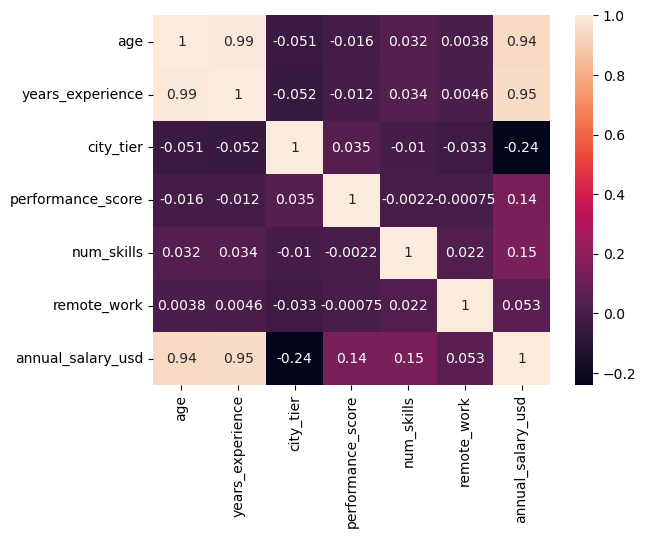

In [13]:
sns.heatmap(corr, annot=True)
plt.show()

In [14]:
sal_data1['education_level'].value_counts()

education_level
Bachelor       258
PhD            256
Master         246
High School    240
Name: count, dtype: int64

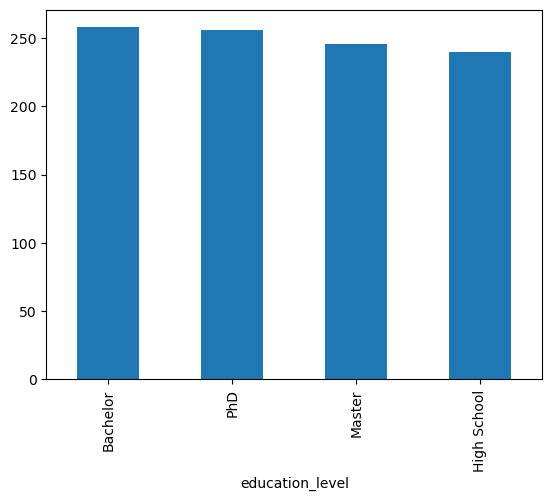

In [15]:
sal_data1['education_level'].value_counts().plot(kind='bar')
plt.show()

In [16]:
sal_data1['job_role'].value_counts()

job_role
DevOps               190
Data Analyst         178
Product Manager      168
QA Engineer          165
Software Engineer    152
ML Engineer          147
Name: count, dtype: int64

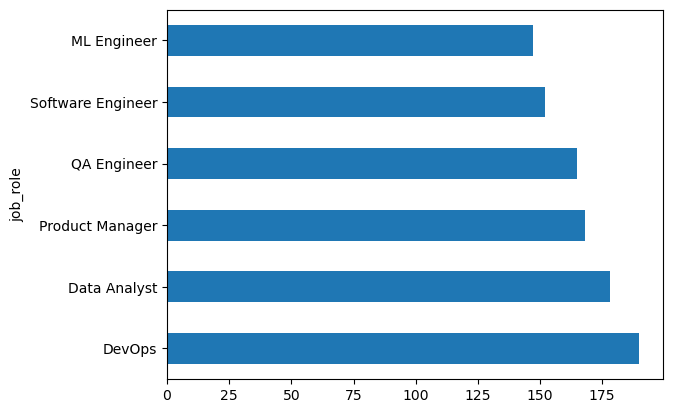

In [17]:
sal_data1['job_role'].value_counts().plot(kind='barh')
plt.show()

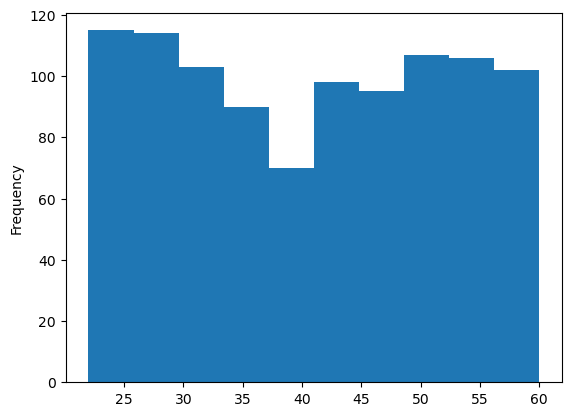

In [18]:
sal_data1['age'].plot(kind='hist')
plt.show()

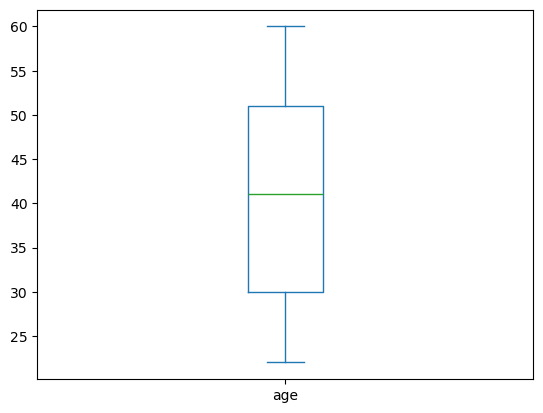

In [19]:
sal_data1['age'].plot(kind='box')
plt.show()

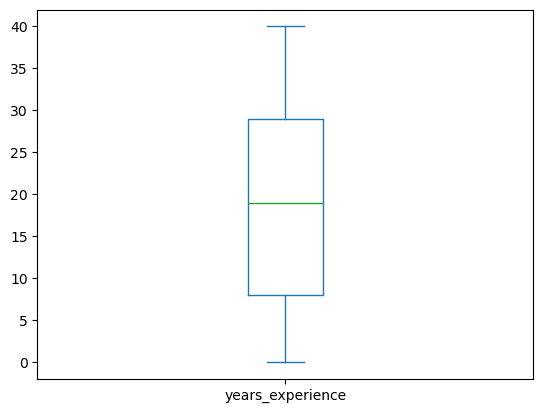

In [20]:
sal_data1['years_experience'].plot(kind='box')
plt.show()

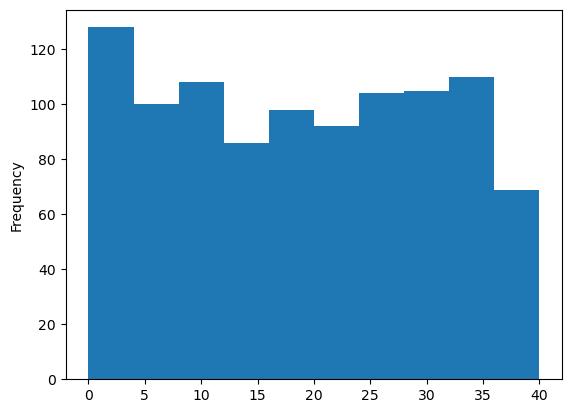

In [21]:
sal_data1['years_experience'].plot(kind='hist')
plt.show()

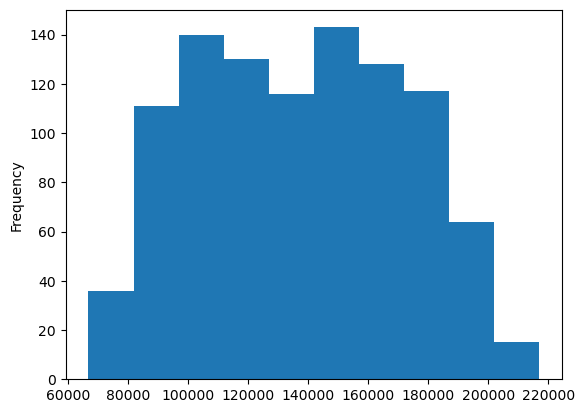

In [22]:
sal_data1['annual_salary_usd'].plot(kind='hist')
plt.show()

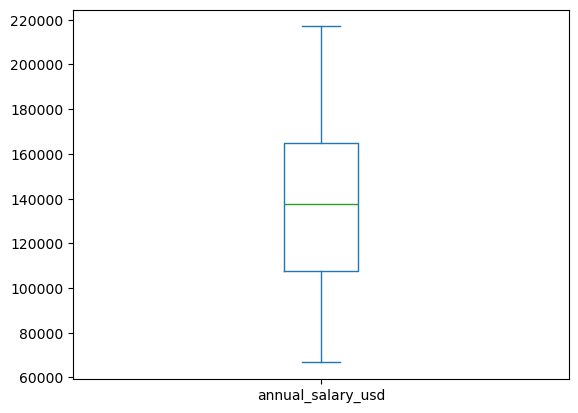

In [23]:
sal_data1['annual_salary_usd'].plot(kind='box')
plt.show()

In [24]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

sal_data1['education_level'] = le.fit_transform(sal_data1['education_level'])
sal_data1['job_role'] = le.fit_transform(sal_data1['job_role'])
sal_data1['employee_id'] = le.fit_transform(sal_data1['employee_id'])

In [25]:
X = sal_data1.drop('annual_salary_usd', axis=1)

y = sal_data1['annual_salary_usd']

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [27]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [28]:
y_pred = model.predict(X_test)

print(y_pred)

[169872.46929325 116383.02056381 165455.9624672   90285.32540327
 181022.88584668  92367.9624347   80231.0861873  151154.46835112
 112275.53558964 144567.22079352 143250.19226915 171878.10365431
 122657.29741748 121089.92720903  88731.85268444 176936.88399738
 169148.45699901 167005.55939225  88429.695667   165632.95846728
 139107.96578611 106586.75384635 176492.52174521 175067.75105309
 162499.4711014  100932.38592252 139319.0990449  149075.37987504
 164452.87463792 160923.03896537 117636.39675035  91474.00242545
  93468.43702722 182943.64730013 120289.12801208 106708.91375282
 109849.24087544 134124.84120547 164614.4057255  183122.53309046
 114611.39442235 185139.56382736 117108.96849258 115967.58567749
 167392.37591471 139758.32789416 127086.86263442 145507.42489704
 112413.93688215 138900.08044176 147458.10765603 154836.76908499
 151035.03895111 174092.26818931 178144.72191306 213704.31221767
  91195.17722716 120270.48149474 133168.63701224  79455.08579832
  83523.9531685  150000.4

In [29]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [30]:
print("MAE :", mean_absolute_error(y_test, y_pred))

MAE : 4137.165141378339


In [31]:
print("MSE :", mean_squared_error(y_test, y_pred))

MSE : 26398441.372683674


In [32]:
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))

RMSE : 5137.94135551231


In [33]:
print("R2 Score :", r2_score(y_test, y_pred))

R2 Score : 0.9799471467272705


In [34]:
result = pd.DataFrame({
    "Actual Salary": y_test,
    "Predicted Salary": y_pred
})

result.head(20)

,Actual Salary,Predicted Salary
521,168471.66,169872.469293
737,112438.67,116383.020564
740,159192.35,165455.962467
660,90415.46,90285.325403
411,178810.86,181022.885847
678,91415.60,92367.962435
626,89375.11,80231.086187
513,152939.73,151154.468351
859,112003.57,112275.535590
136,139257.76,144567.220794


In [35]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 4137.165141378339
MSE: 26398441.372683674
RMSE: 5137.94135551231
R2 Score: 0.9799471467272705
